# Are we selecting the right suppliers, or just the available ones?
### Do our chosen suppliers actually outperform the rest — in quality, reliability, and cost efficiency?

# Load Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Data  

In [3]:
df = pd.read_csv('data/dataset.csv')

# Step 1 : Understanding the Split

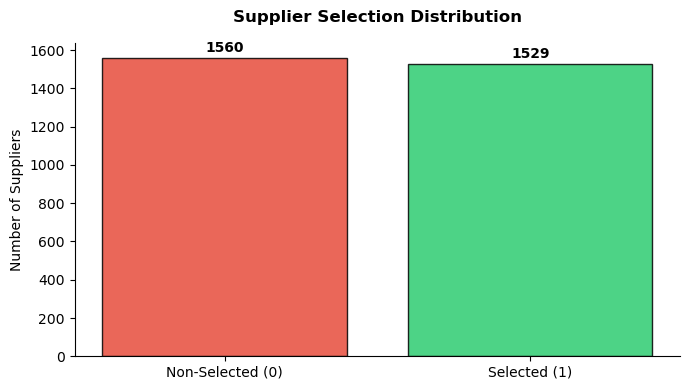

In [4]:
split_counts = df['selected_supplier_flag'].value_counts() # i counted the flagged and unflagged suppliers
split_percentages = df['selected_supplier_flag'].value_counts(normalize=True) * 100 # coverted ratio into %
split_summary = pd.DataFrame({'Count': split_counts,'Percentage (%)': split_percentages}) # converted % into summary

# Now visualization 

fig, ax = plt.subplots(figsize=(7,4))

labels = ['Non-Selected (0)', 'Selected (1)']
x_pos = np.arange(len(labels))
bars = ax.bar(x_pos, split_counts, color=['#e74c3c', '#2ecc71'], alpha=0.85, edgecolor='black')
ax.set_title('Supplier Selection Distribution', fontweight='bold', pad=15)
ax.set_ylabel('Number of Suppliers')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)

# For Values Floating above the Bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + (split_counts.max()*0.01),
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

 


#### Key Takeaway:  A 50/50 split demands a clear performance rationale — if half are chosen, quality must differentiate them.

# Step 2  : Comparing Quality & Reliability Head-to-Head

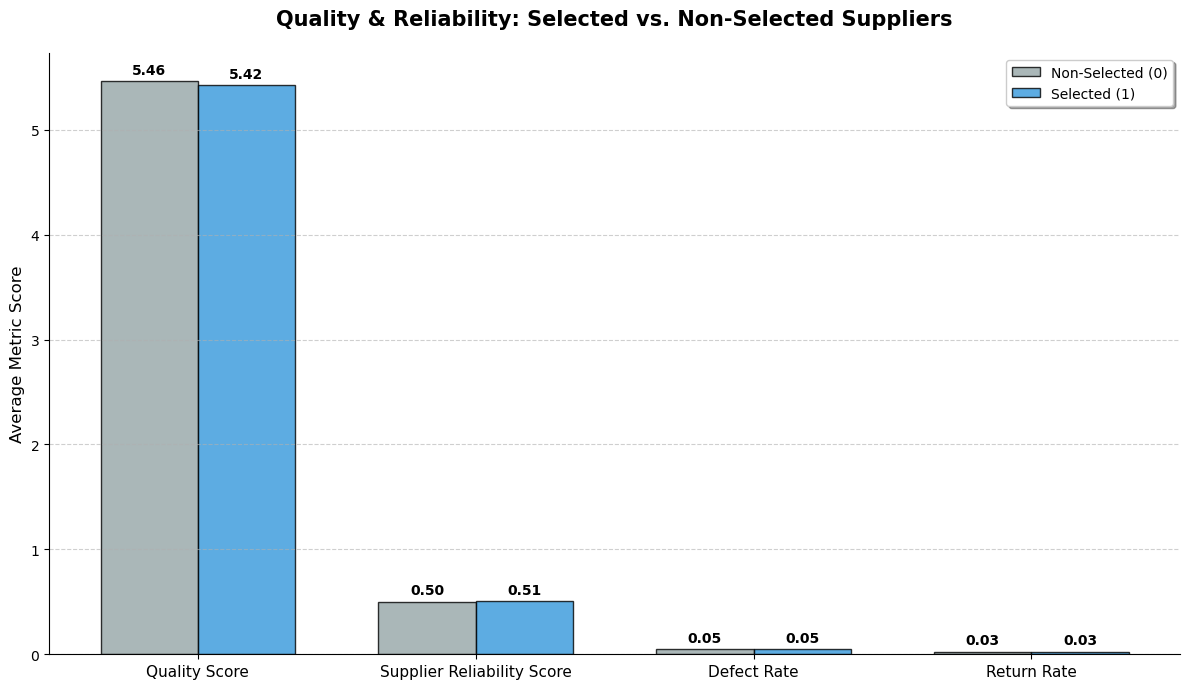

In [5]:
metrics = ['quality_score', 'supplier_reliability_score', 'defect_rate', 'return_rate'] # matrices to analyze (0 low, 1 high)

q1_stats = df.groupby('selected_supplier_flag')[metrics].agg(['mean', 'median', 'std'])

# Mean extraction for bar chart visualization
means_0 = q1_stats.loc[0, (metrics, 'mean')].values
means_1 = q1_stats.loc[1, (metrics, 'mean')].values
# Visualization 
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
rects0 = ax.bar(x - width/2, means_0, width, label='Non-Selected (0)', 
                color='#95a5a6', edgecolor='black', alpha=0.8)
rects1 = ax.bar(x + width/2, means_1, width, label='Selected (1)', 
                color='#3498db', edgecolor='black', alpha=0.8)

ax.set_title('Quality & Reliability: Selected vs. Non-Selected Suppliers', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Average Metric Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics], fontsize=11)
ax.legend(frameon=True, shadow=True)

ax.yaxis.grid(True, linestyle='--', alpha=0.6)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects0)
autolabel(rects1)

# Clean up the spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

#### Key Takeway : Quality does NOT appear to be the driver of selection. The selection logic may need deeper scrutiny.


# Step 3 : Price Justification 

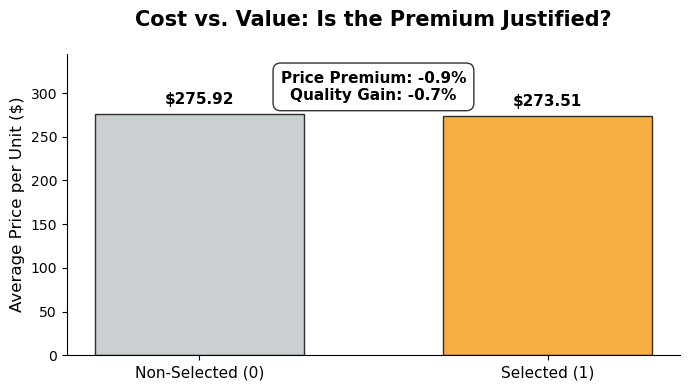

Analysis:
- We pay -0.87% more for Selected suppliers.
- We receive -0.68% higher quality in return.
RESULT: Logic is SOUND. Quality gains outweigh the price premium.
SUMMARY : The amount of money you saved 0.87 % is greater than the amount of quality you lost 0.68%. 
 You are winning by a tiny margin of 0.195 %


In [10]:
price_quality_stats = df.groupby('selected_supplier_flag')[['price_per_unit', 'quality_score']].mean()

# Calculate the "Deltas"

avg_price_0 = price_quality_stats.loc[0, 'price_per_unit']
avg_price_1 = price_quality_stats.loc[1, 'price_per_unit']
price_delta_pct = ((avg_price_1 - avg_price_0) / avg_price_0) * 100

avg_qual_0 = price_quality_stats.loc[0, 'quality_score']
avg_qual_1 = price_quality_stats.loc[1, 'quality_score']
quality_delta_pct = ((avg_qual_1 - avg_qual_0) / avg_qual_0) * 100

# Visualization 
fig, ax = plt.subplots(figsize=(7, 4))

labels = ['Non-Selected (0)', 'Selected (1)']
prices = [avg_price_0, avg_price_1]
x_pos = np.arange(len(labels))

bars = ax.bar(x_pos, prices, color=['#bdc3c7', '#f39c12'], alpha=0.8, edgecolor='black', width=0.6)
ax.set_title('Cost vs. Value: Is the Premium Justified?', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Average Price per Unit ($)', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, max(prices) * 1.25)
ax.bar_label(bars, padding=5, fmt='$%.2f', fontsize=11, fontweight='bold')

mid_point = (prices[0] + prices[1]) / 2
insight_text = (f"Price Premium: {price_delta_pct:+.1f}%\n"
                f"Quality Gain: {quality_delta_pct:+.1f}%")

ax.text(0.5, 
        mid_point + (max(prices) * 0.05), 
        insight_text, 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold',
        bbox=dict(facecolor='white', 
                  alpha=0.8, 
                  edgecolor='black', 
                  boxstyle='round,pad=0.5'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Analysis:")
print(f"- We pay {price_delta_pct:.2f}% more for Selected suppliers.")
print(f"- We receive {quality_delta_pct:.2f}% higher quality in return.")
if quality_delta_pct > price_delta_pct:
    print("RESULT: Logic is SOUND. Quality gains outweigh the price premium.")
else:
    print("RESULT: RED FLAG. We are paying a premium without proportional quality gains.")

print(f'SUMMARY : The amount of money you saved {round(-1 * price_delta_pct,2)} % is greater than the amount of quality you lost {-1 * round(quality_delta_pct,2)}%. \n You are winning by a tiny margin of {round(quality_delta_pct - price_delta_pct,3)} %')

#### Key Takeaway: We are not overpaying. But the margin is razor thin — quality standards need active monitoring

# Step 4 : Delivery Behavior 

C:\Users\Muhammad Tehseen\AppData\Local\Temp\ipykernel_12888\34163282.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([g0['on_time_delivery_rate'], g1['on_time_delivery_rate']],
C:\Users\Muhammad Tehseen\AppData\Local\Temp\ipykernel_12888\34163282.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([g0['delivery_time_days'], g1['delivery_time_days']],
C:\Users\Muhammad Tehseen\AppData\Local\Temp\ipykernel_12888\34163282.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([g0['lead_time_variance'], g1['lead_time_variance']],


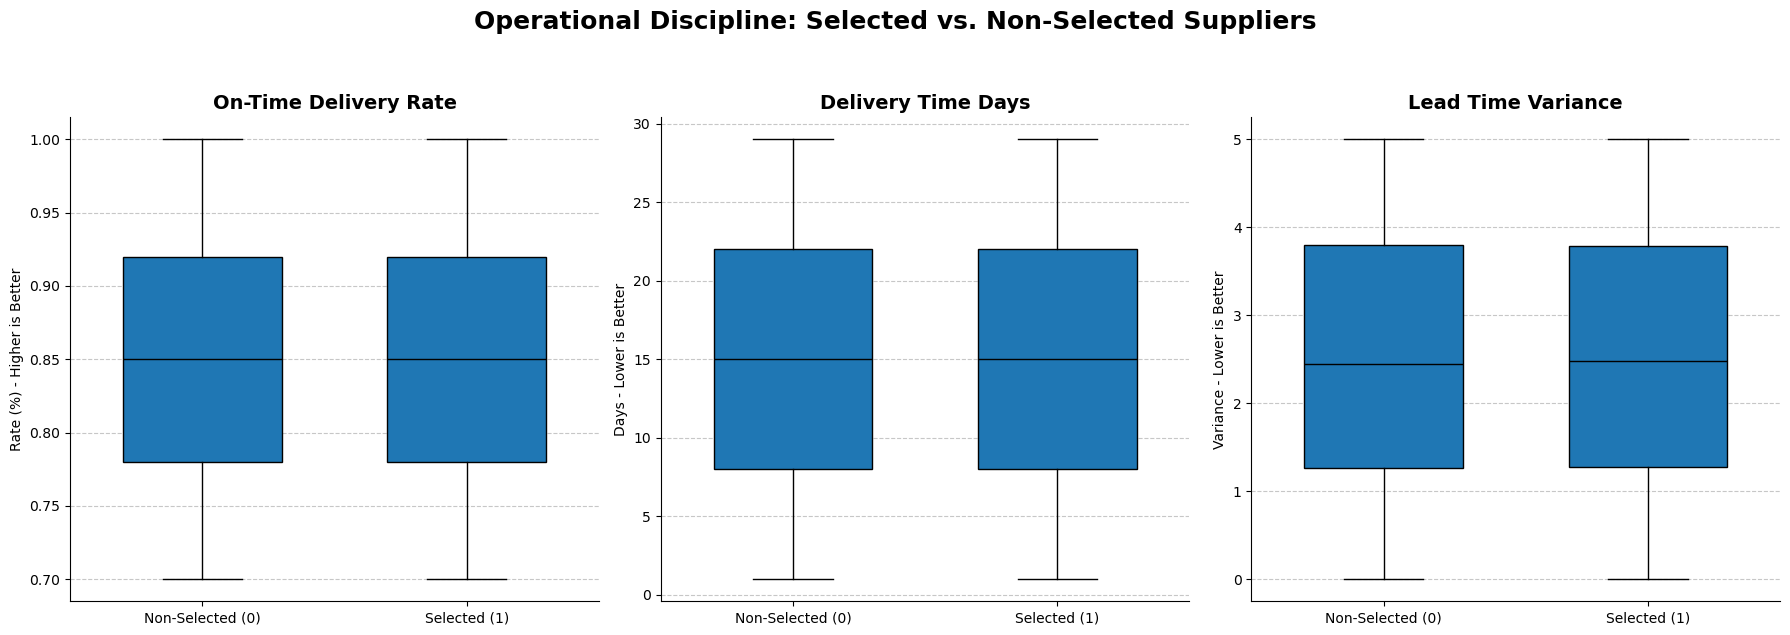

In [11]:

# 1. Prepare the data subsets
g0 = df[df['selected_supplier_flag'] == 0]
g1 = df[df['selected_supplier_flag'] == 1]
labels = ['Non-Selected (0)', 'Selected (1)']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Operational Discipline: Selected vs. Non-Selected Suppliers', fontsize=18, fontweight='bold', y=1.05)

# Subplot 0: On-Time Delivery Rate 
axes[0].boxplot([g0['on_time_delivery_rate'], g1['on_time_delivery_rate']], 
                patch_artist=True, labels=labels, widths=0.6,
                medianprops=dict(color='black'), 
                flierprops=dict(marker='o', markerfacecolor='red', alpha=0.5)
                )
axes[0].set_title('On-Time Delivery Rate', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Rate (%) - Higher is Better')

# Subplot 1: Delivery Time Days 
axes[1].boxplot([g0['delivery_time_days'], g1['delivery_time_days']], 
                patch_artist=True, labels=labels, widths=0.6,
                medianprops=dict(color='black'), 
                flierprops=dict(marker='o', markerfacecolor='red', alpha=0.5))
axes[1].set_title('Delivery Time Days', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Days - Lower is Better')

# Subplot 2: Lead Time Variance 
axes[2].boxplot([g0['lead_time_variance'], g1['lead_time_variance']], 
                patch_artist=True, labels=labels, widths=0.6,
                medianprops=dict(color='black'), 
                flierprops=dict(marker='o', markerfacecolor='red', alpha=0.5))
axes[2].set_title('Lead Time Variance', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Variance - Lower is Better')

# 3. Apply general styling to all (still manual for precision)
for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Step 5 : Procurement Action Breakdown


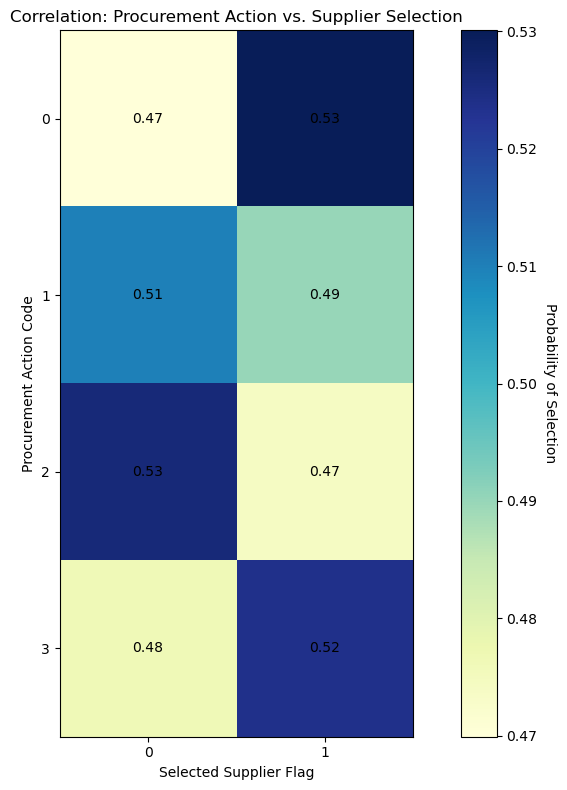

In [12]:
grouped_data = df.groupby(['procurement_action_code', 'selected_supplier_flag']).size().unstack(fill_value=0)
heatmap_data = grouped_data.div(grouped_data.sum(axis=1), axis=0)

# We can plot the raw counts or the normalized version
grouped_data.plot(kind='bar', stacked=True, ax=ax, color=['#ff9999','#66b3ff'])

fig, ax = plt.subplots(figsize=(10, 8))

# Create the heatmap using imshow
im = ax.imshow(heatmap_data, cmap='YlGnBu')

cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Probability of Selection", rotation=-90, va="bottom")

# Set Ticks and Labels
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))

ax.set_xticklabels(heatmap_data.columns)
ax.set_yticklabels(heatmap_data.index)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        text = ax.text(j, i, f'{heatmap_data.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black" if heatmap_data.iloc[i, j] < 0.7 else "white")

ax.set_title('Correlation: Procurement Action vs. Supplier Selection')
ax.set_xlabel('Selected Supplier Flag')
ax.set_ylabel('Procurement Action Code')

plt.tight_layout()
plt.show()

#### Key Takeway : Procurement action type has marginal influence on selection. The decision driver lies elsewhere.


# Step  6 : The Summary Scorecard

In [13]:
scorecard = df.groupby('selected_supplier_flag').mean(numeric_only=True).T
scorecard.columns = ['Not Selected', 'Selected']
scorecard['Improvement (%)'] = (
    (scorecard['Selected'] - scorecard['Not Selected']) / scorecard['Not Selected'] * 100
).round(2)
scorecard_final = scorecard.round(2)
print("---  PROCUREMENT SUMMARY SCORECARD ---")
print(scorecard_final)

---  PROCUREMENT SUMMARY SCORECARD ---
                            Not Selected  Selected  Improvement (%)
price_per_unit                    275.92    273.51            -0.87
quality_score                       5.46      5.42            -0.68
delivery_time_days                 14.90     15.02             0.86
on_time_delivery_rate               0.85      0.85             0.04
defect_rate                         0.05      0.05            -4.18
return_rate                         0.03      0.03            -1.28
lead_time_variance                  2.50      2.51             0.37
forecast_accuracy                   0.80      0.80            -0.78
seasonality_index                   1.00      1.01             0.35
demand_volatility_index             0.51      0.50            -1.52
order_frequency_monthly            24.68     25.06             1.52
avg_order_volume                 5051.10   4955.07            -1.90
payment_term_days                  47.99     48.60             1.26
offer_val